## RAG
## Foundation Models in the Generation Phase

During the generation step, language models:

- Read the **retrieved context**
- Analyze the **user’s question**
- Generate a response that is **grounded in the retrieved information**

In [1]:
%pip install openai==2.21.0 anthropic==0.18.1 python-dotenv==1.0.0 httpx==0.27.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.1/848.1 kB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 6.5 MB/s eta 0:00:00
  Attempting uninstall: python-dotenv
    Found existing installation: python-dotenv 1.2.1
    Uninstalling python-dotenv-1.2.1:
      Successfully uninstalled python-dotenv-1.2.1
  Attempting uninstall: httpx
    Found existing installation: httpx 0.28.1
    Uninstalling httpx-0.28.1:
      Successfully uninstalled httpx-0.28.1
  Attempting uninstall: openai
    Found existing installation: openai 2.23.0
    Uninstalling openai-2.23.0:
      Successfully uninstalled openai-2.23.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mcp 1.26.0 requires httpx>=0.27.1, but you have httpx 0.27.0 which is incompatible.
google-genai 1.64.0

## Generating Content Using the OpenAI API

### Load secrets

If you run this code in Google Colab, save your OpenAI API key in the secrets and access it by

In [2]:
import os
import sys
from dotenv import load_dotenv

# Check if running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    try:
        from google.colab import userdata  # type: ignore

        os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
        os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY")
        os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
    except ModuleNotFoundError:
        pass
else:
    load_dotenv()

### Load sample files

This notebook uses sample Word and PDF files.

When running the notebook on Google Colab, uncomment the code below to download the `datasets` directory from the Github repo.

In [3]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !git clone --no-checkout https://github.com/polzerdo55862/RAG-with-Python-Cookbook.git
    %cd RAG-with-Python-Cookbook
    !git sparse-checkout init --cone
    !git sparse-checkout set datasets
    !git checkout
    !cp -r datasets /content/datasets
    print("\u2713 Datasets downloaded to /content/datasets")
else:
    print("\u26a0 Running locally. Using ../datasets/ directory")

Cloning into 'RAG-with-Python-Cookbook'...
remote: Enumerating objects: 1602, done.
remote: Counting objects: 100% (342/342), done.
remote: Compressing objects: 100% (158/158), done.
remote: Total 1602 (delta 233), reused 228 (delta 181), pack-reused 1260 (from 2)
Receiving objects: 100% (1602/1602), 42.77 MiB | 14.45 MiB/s, done.
Resolving deltas: 100% (917/917), done.
/content/RAG-with-Python-Cookbook
Your branch is up to date with 'origin/main'.
✓ Datasets downloaded to /content/datasets


## 1. OpenAI Chat Completions

In [4]:
# Import the OpenAI client
from openai import OpenAI


# Function that asks a question using provided context
def ask_with_context(context, question):
    # Create an OpenAI client instance
    client = OpenAI()

    # Build the message list for the chat completion
    messages = [
        {
            # System message sets behavior constraints for the model
            # This tells the model to rely only on the given context
            "role": "system",
            "content": "Answer based only on the provided context."
        },
        {
            # User message contains both the context and the question
            # The model will read this information to generate the answer
            "role": "user",
            "content": f"Context:\n{context}\n\nQuestion:\n{question}"
        },
    ]

    # Send the messages to the OpenAI Chat Completions API
    response = client.chat.completions.create(
        # Lightweight model suitable for fast, context-based answers
        model="gpt-4o-mini",
        messages=messages
    )

    # Extract and return the generated answer text
    return response.choices[0].message.content


# Example usage of the function

# Context provided to the model
context = "RAG stands for Retrieval-Augmented Generation."

# Question that should be answered using only the context
question = "What does RAG stand for?"

# Get the model's answer
answer = ask_with_context(context, question)

# Print the final answer
print(answer)

RAG stands for Retrieval-Augmented Generation.


- Using hosted foundation models requires minimal setup—API key, HTTP client, and you’re generating text. Choosing between providers matters when you have specific constraints around cost, context windows, or regulatory requirements.

- OpenAI’s rate limits and throughput typically exceed competitors for high-volume production deployments. Switch to Google or Anthropic when you need longer context windows, cheaper high-volume inference, or specific multimodal capabilities.

- GPT-5 handles complex reasoning, structured outputs, and tool use. For latency-sensitive workloads where speed matters more than maximum reasoning depth, consider GPT-4.1 or smaller variants like GPT-5-mini. GPT-4.1 optimizes for low latency and high throughput, making it better for real-time chat and customer support.

## Generating Content Using Google’s Gemini Models

##### Problem
- You want to use Google’s Gemini models to generate and analyze text and images.

#### Solution
- Google aligned its API with OpenAI client library conventions, so you can reuse the same SDK. You only change the base URL so that the client sends requests to Google’s generative language endpoint instead of OpenAI’s.

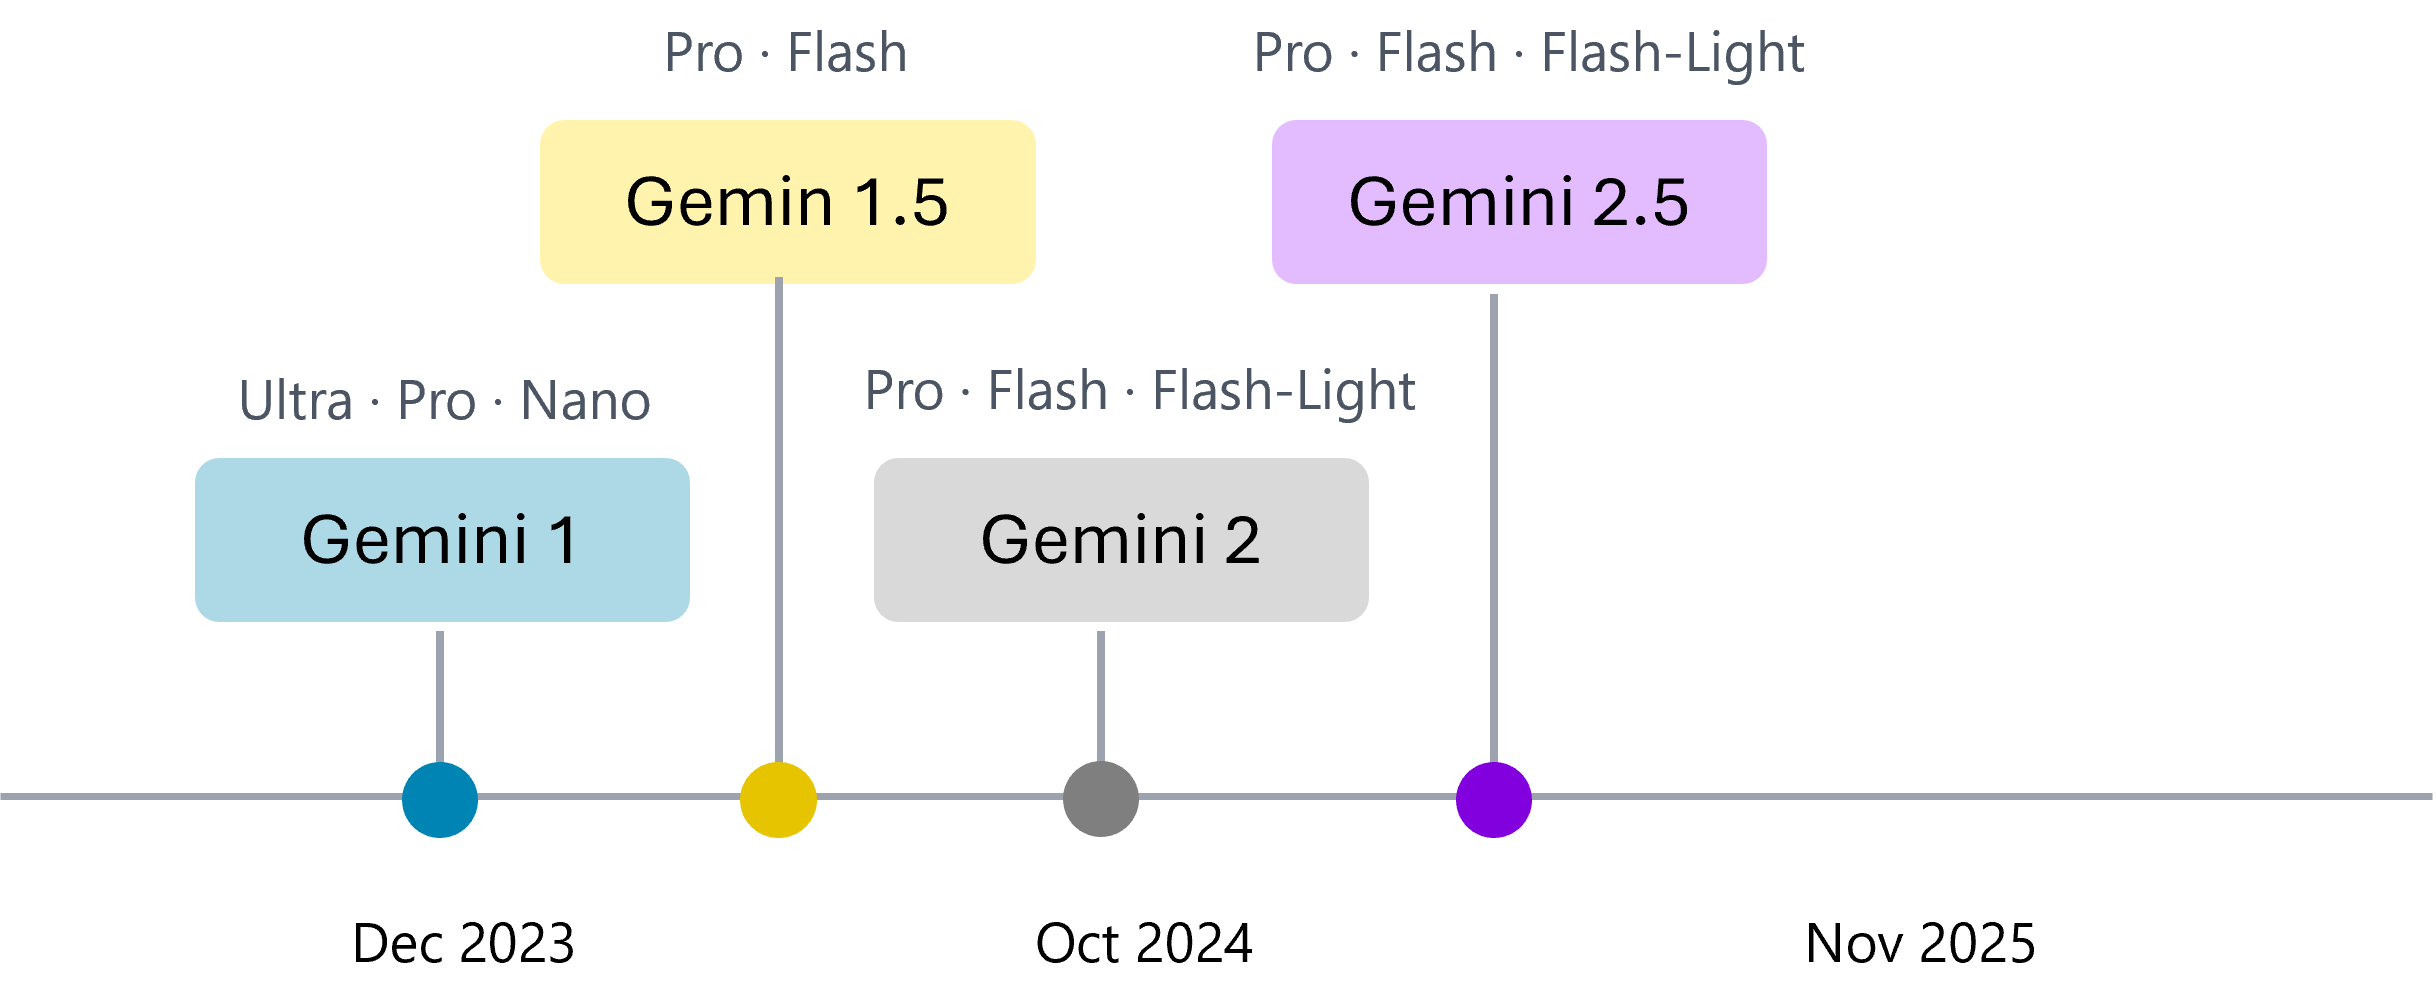

In [3]:
from IPython.display import Image, display
display(Image(filename="images/rwpc_0205.png", width=500, height=500))

To use Gemini, you need an API key from Google AI Studio. Create a key with a few clicks and store it in an environment variable named GOOGLE_API_KEY. The example below reads the key from this variable.

The following code creates an OpenAI client that connects to Google instead of OpenAI. The structure is identical to using an OpenAI model. The only difference is the base URL defined when creating the client.

## 2. OpenAI Whisper Speech-to-Text

In [6]:
from openai import OpenAI
import os

client = OpenAI()

# Determine the correct path based on environment
if IN_COLAB:
    audio_path = "/content/datasets/audio_files/harvard.wav"
else:
    audio_path = "../datasets/audio_files/harvard.wav"

with open(audio_path, "rb") as audio_file:
    transcript = client.audio.transcriptions.create(
        model="whisper-1",
        file=audio_file,
    )

print(transcript.text)

The stale smell of old beer lingers. It takes heat to bring out the odor. A cold dip restores health and zest. A salt pickle tastes fine with ham. Tacos al pastor are my favorite. A zestful food is the hot cross bun.


## Generating Content Using the Anthropic API

#### Problem
You want to use Anthropic’s Claude models to analyze content and generate text.

#### Solution
Anthropic provides a strong alternative to OpenAI and Google, especially when you need precise reasoning, reliable coding support, or mathematically accurate outputs.

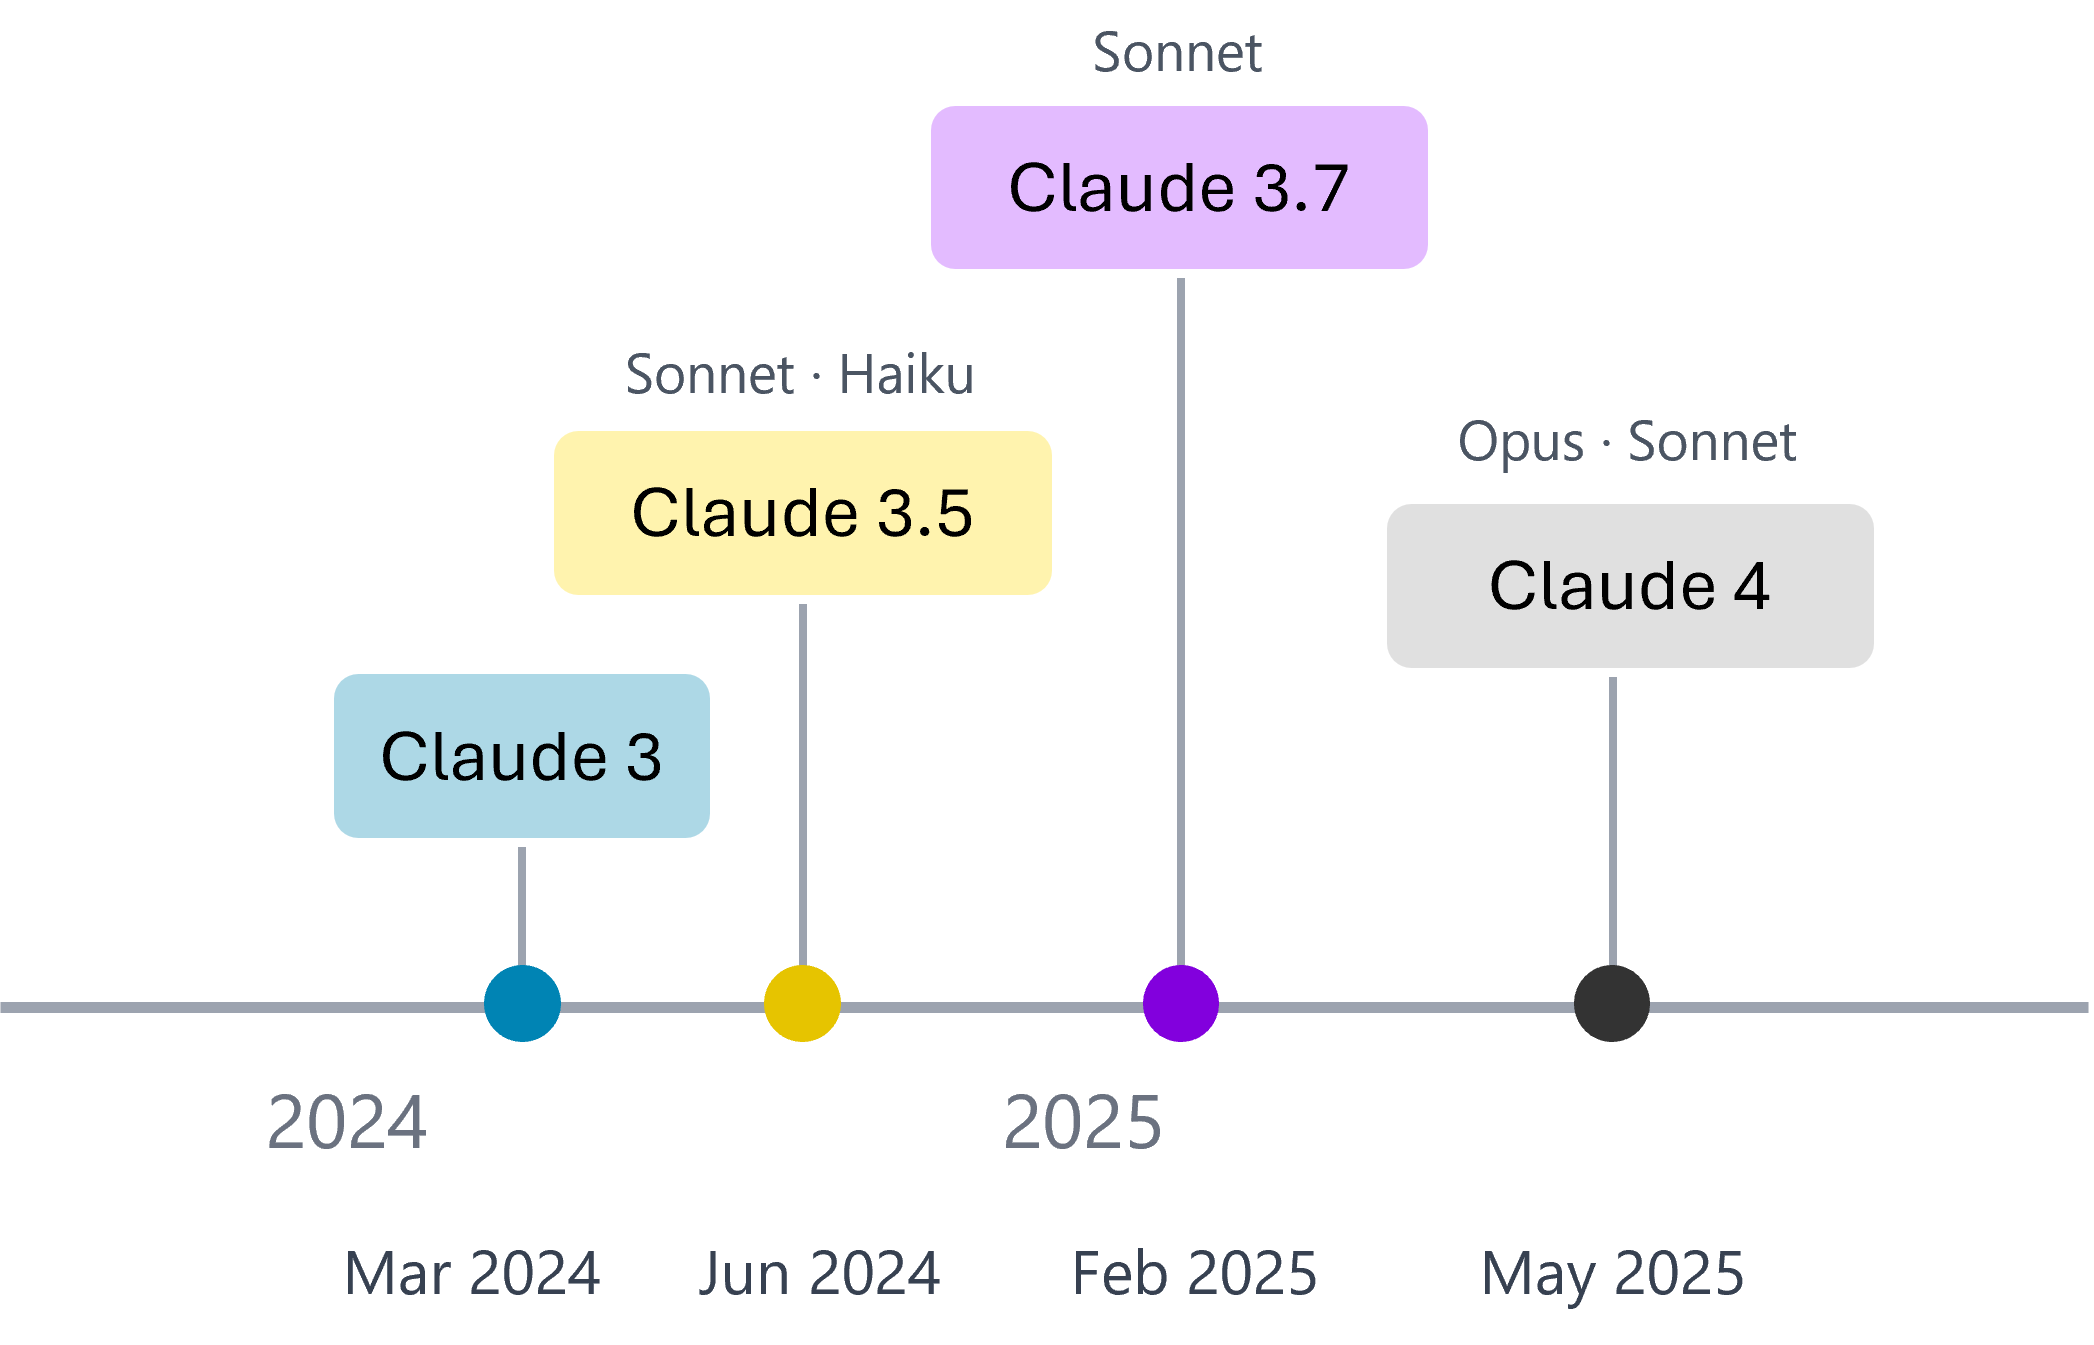

In [4]:
display(Image(filename="images/rwpc_0206.png", width=500, height=500))

To use the Anthropic API, create an account on the Anthropic website and generate an API key. You can generate the key in the Anthropic Console under the API section. Purchasing a small amount of credits is required. Five dollars is usually enough to run the examples in this book. Store the key as an environment variable named ANTHROPIC_API_KEY so the Anthropic SDK can locate it.

While Google provides an OpenAI compatible endpoint, Anthropic uses its own protocol, which does not match what the OpenAI SDK expects. Because of this, you need to use the Anthropic SDK.

## 3. Anthropic Claude Example

In [7]:
client.models.list()

SyncPage[Model](data=[Model(id='gpt-4-0613', created=1686588896, object='model', owned_by='openai'), Model(id='gpt-4', created=1687882411, object='model', owned_by='openai'), Model(id='gpt-3.5-turbo', created=1677610602, object='model', owned_by='openai'), Model(id='gpt-4o-search-preview-2025-03-11', created=1771905621, object='model', owned_by='system'), Model(id='gpt-5.3-codex', created=1770537915, object='model', owned_by='system'), Model(id='gpt-realtime-1.5', created=1771461469, object='model', owned_by='system'), Model(id='gpt-audio-1.5', created=1771550885, object='model', owned_by='system'), Model(id='gpt-4o-search-preview', created=1771905534, object='model', owned_by='system'), Model(id='davinci-002', created=1692634301, object='model', owned_by='system'), Model(id='babbage-002', created=1692634615, object='model', owned_by='system'), Model(id='gpt-3.5-turbo-instruct', created=1692901427, object='model', owned_by='system'), Model(id='gpt-3.5-turbo-instruct-0914', created=1694

In [8]:
# Import the Anthropic client for interacting with Claude models
from anthropic import Anthropic

# Import os to access environment variables
import os


# Create an Anthropic client using the API key stored in an environment variable
# This avoids hardcoding secrets directly in the code
client = Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])


# Send a message to a Claude model
response = client.messages.create(
    # Specify the Claude model to use
    model="claude-sonnet-4-5-20250929",

    # Maximum number of tokens the model is allowed to generate
    max_tokens=200,

    # Messages follow a role-based structure
    messages=[
        {
            # The user role represents the prompt sent to the model
            "role": "user",

            # The actual question or instruction for the model
            "content": "Explain how vector databases work in "
                       "simple terms.",
        }
    ],
)


# Claude responses may contain multiple content blocks
# This prints the text from the first block
print(response.content[0].text)

# Vector Databases in Simple Terms

## The Basic Idea

Think of a vector database like a library that organizes books by their **meaning** rather than alphabetically. It finds similar items by understanding what they're actually about.

## How It Works

**1. Converting to Vectors**
- Everything (text, images, audio) gets converted into a list of numbers called a "vector"
- Similar items have similar number patterns
- Example: "cat" and "kitten" would have very similar vectors, while "cat" and "car" would be quite different

**2. Storing**
- These vectors are stored in a way that makes finding similar items fast
- Like organizing items on a map where similar things are clustered together

**3. Searching**
- When you search, your query also becomes a vector
- The database finds vectors closest to yours (like finding the nearest neighbors on a map)
- Returns


## Claude Models: Strengths and Trade-offs

In practice, Claude models tend to:
- Produce **longer, more detailed explanations**
- Explicitly highlight ambiguities or missing information
- Avoid selecting a plausible answer when certainty is low

This makes Claude well suited for tasks where **conservative reasoning matters more than speed**.

---

## When to Choose Claude

Claude models are a strong choice when correctness and caution are critical, such as:

- Legal document review  
- Compliance and policy analysis  
- Code generation that requires careful reasoning  
- Complex mathematical problems  
- Multi-step logical reasoning tasks  

Claude’s extended reasoning behavior helps surface assumptions and edge cases that faster models may gloss over.

---

## When Not to Use Claude

Claude is not ideal for every workload.

Avoid using Claude when:
- Building **high-throughput chatbots** with simple queries
- Users expect **near-instant responses**
- You need the **lowest possible latency** for batch processing

Claude’s deliberate reasoning style trades speed for thoroughness, which can be unnecessary for straightforward tasks.

---

## Claude Model Tiers

Anthropic offers Claude models in multiple sizes, following a structure similar to other major providers:

- **Claude Haiku**  
  - Optimized for high-volume, cost-efficient workloads  
  - Suitable for simpler tasks and fast responses

- **Claude Sonnet**  
  - Strong all-around performance  
  - Balances reasoning ability, speed, and cost

- **Claude Opus**  
  - Designed for deep reasoning and complex tasks  
  - Best suited for demanding analytical workloads

This tiered approach closely parallels model families offered by OpenAI and Google, making it easier to choose the right model based on task complexity.

---

## Key Takeaway

👉 Choose Claude when **explicit reasoning, ambiguity handling, and correctness** matter more than raw speed.  
For simple, high-volume, or latency-sensitive tasks, faster model families are usually a better fit.

## 4. Gemini API Example using the OpenAI SDK

In [9]:
import os
from openai import OpenAI

client = OpenAI(
    api_key=os.getenv("GOOGLE_API_KEY"),
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/",
)

client.models.list()

SyncPage[Model](data=[Model(id='models/gemini-2.5-flash', created=None, object='model', owned_by='google', display_name='Gemini 2.5 Flash'), Model(id='models/gemini-2.5-pro', created=None, object='model', owned_by='google', display_name='Gemini 2.5 Pro'), Model(id='models/gemini-2.0-flash', created=None, object='model', owned_by='google', display_name='Gemini 2.0 Flash'), Model(id='models/gemini-2.0-flash-001', created=None, object='model', owned_by='google', display_name='Gemini 2.0 Flash 001'), Model(id='models/gemini-2.0-flash-exp-image-generation', created=None, object='model', owned_by='google', display_name='Gemini 2.0 Flash (Image Generation) Experimental'), Model(id='models/gemini-2.0-flash-lite-001', created=None, object='model', owned_by='google', display_name='Gemini 2.0 Flash-Lite 001'), Model(id='models/gemini-2.0-flash-lite', created=None, object='model', owned_by='google', display_name='Gemini 2.0 Flash-Lite'), Model(id='models/gemini-2.5-flash-preview-tts', created=None

In [10]:
import os
from openai import OpenAI

client = OpenAI(
    api_key=os.getenv("GOOGLE_API_KEY"),
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/",
)

resp = client.chat.completions.create(
    model="gemini-2.5-flash",
    messages=[
        {"role": "user", "content": "What is the capital of France?"}
    ],
)

print(resp.choices[0].message.content)

The capital of France is **Paris**.


### Running Open Source Models Locally with Ollama

### Problem
You need to run language models locally because your data is too sensitive to send to external providers, or because self-hosting is more cost-effective at your API call volume.

### Solution
A simple way to run models privately is Ollama. It is a free open source tool that lets you run open source LLMs directly on your own machine. Once installed, it starts a local service that behaves like the remote API endpoints from OpenAI and Google.

Before you can call Ollama from your Python code, you need two things:

The Ollama runtime installed on your machine

At least one local model downloaded and ready to use

Ollama is not a Python package. It is a system tool that runs a small local server in the background. This server loads the model, performs inference, and exposes an API on localhost:11434 that your Python code can call.

To install Ollama, follow the instructions at Download Ollama. Installers are available for macOS, Windows, and Linux.

Once Ollama is installed, you still need to download the models you want to run. You do this with simple ollama pull commands. These commands fetch the model weights and store them locally so the model is ready to run.

The following code snippet shows how to pull three popular models, Llama 2, Mistral, and CodeLlama. You can choose other models as well. A full list is available at Ollama Models.

Once Ollama is running, you can call it like any other API. The simplest approach is to reuse the same OpenAI SDK used for the OpenAI and Gemini APIs. Ollama exposes an OpenAI compatible endpoint at http://localhost:11434/v1, so your existing code barely needs to change.

The code snippet below shows how to use the OpenAI client to call a local Ollama model. You create a client that points to the local endpoint instead of OpenAI’s servers, then send your prompt exactly as before. The only differences are the base_url and the model name.

The code snippet below shows how to use the OpenAI client to call a local Ollama model. You create a client that points to the local endpoint instead of OpenAI’s servers, then send your prompt exactly as before. The only differences are the base_url and the model name.

## 5. Deploy local LLMs using Ollama

### Setting up Ollama in Colab

Since Colab runs in a cloud environment, you need to install and run Ollama directly within the Colab instance. The following steps will set up Ollama and pull the required models.

In [ ]:
import subprocess
import os

# Install zstd dependency
!sudo apt-get update && sudo apt-get install -y zstd

# Install Ollama
!curl -fsSL https://ollama.com/install.sh | sh

# Start Ollama server in the background
os.environ['OLLAMA_HOST'] = '0.0.0.0'
subprocess.Popen(["ollama", "serve"])

print("Ollama server is starting...")

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,613 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,115 kB]
Fetched 6,112 kB in 3s (1,924 kB/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem

In [12]:
# Give Ollama some time to ensure it's fully started (adjust if needed)
import time
time.sleep(10)

print("Pulling models...")
!ollama pull qwen3:4b
!ollama pull llama2
!ollama pull mistral
!ollama pull codellama

print("Models pulled successfully. You can now re-run the Ollama examples.")

Pulling models...




Models pulled successfully. You can now re-run the Ollama examples.


In [13]:
from openai import OpenAI

# Point the client to your local Ollama server
client = OpenAI(
    base_url="http://localhost:11434/v1",
    api_key="ollama",  # Ollama does not require a real key,
                       # but the SDK expects one
)

response = client.chat.completions.create(
    model="qwen3:4b",
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {
            "role": "user",
            "content": "What is retrieval augmented generation?"
        },
    ],
)

print(response.choices[0].message.content)

APITimeoutError: Request timed out.

In [ ]:
from openai import OpenAI

models = ["llama2", "mistral", "codellama"]
client = OpenAI(
    base_url="http://localhost:11434/v1",
    api_key="ollama"
)

for model in models:
    print(f"\n--- Testing {model} ---")
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "user", "content": "Explain RAG in one sentence."}
        ]
    )
    print(response.choices[0].message.content)

### Creating Structured Outputs with the OpenAI SDK and Pydantic

### Problem
You want to extract insights from text and images, while ensuring the output from LLM and multimodal models follows a predefined schema with the correct data types.

### Solution
The OpenAI SDK lets you define a response schema using a Pydantic model. This schema describes the fields and their data types that the model should return. Instead of working with raw JSON, the SDK validates the model output and returns a typed Python object.

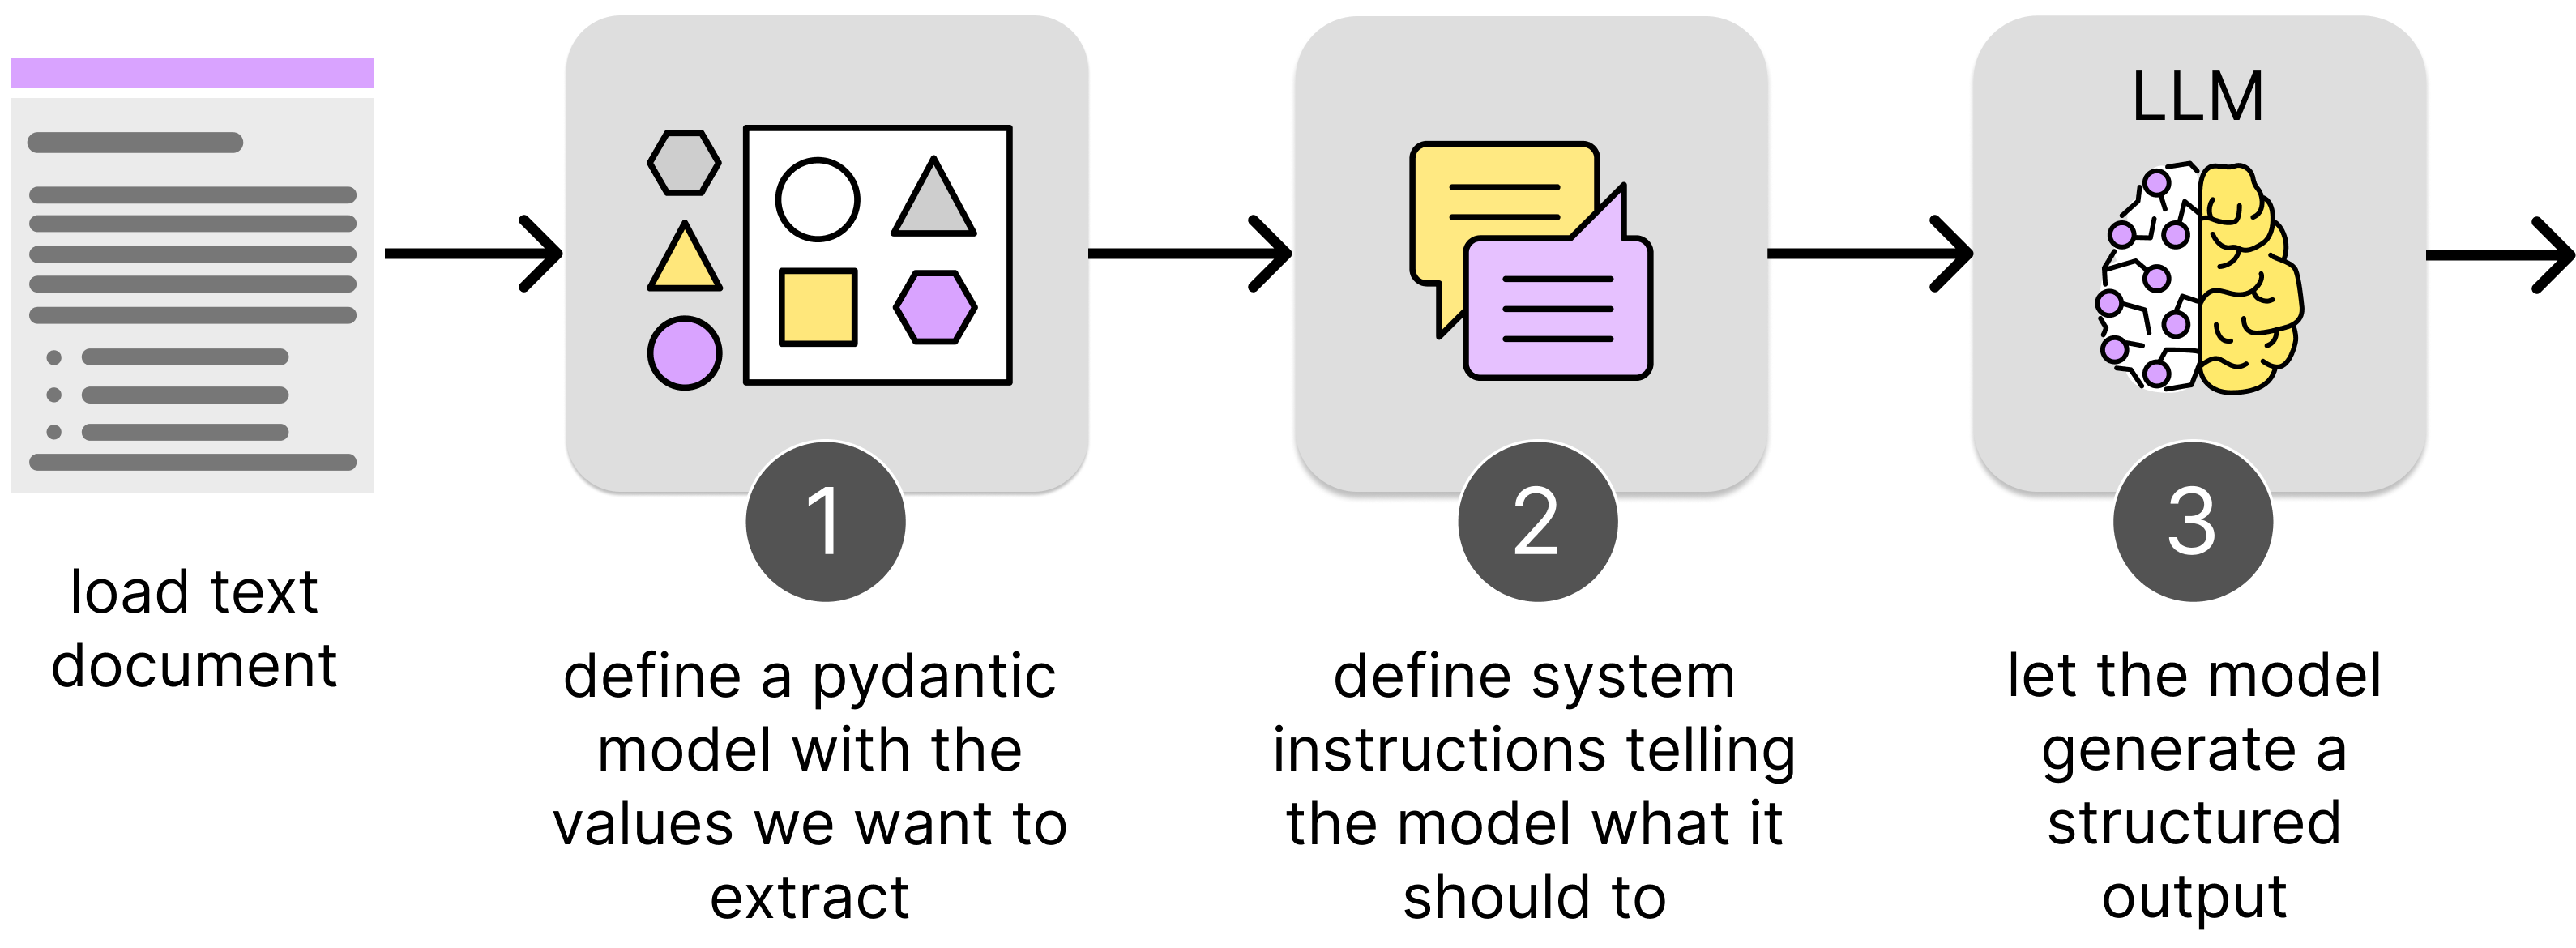

In [5]:
display(Image(filename="images/rwpc_0207.png", width=500, height=500))

You start by defining the structure you want the model to fill. The code in the following example defines Python objects for invoice extraction with nested structures using Pydantic’s BaseModel class. It creates a LineItem to represent individual items on an invoice, and Invoice to represent the complete invoice with multiple line items. Every Pydantic model must extend BaseModel because it provides automatic type validation and parsing methods that convert raw model output into clean Python objects.

Structured outputs enforce a schema at inference time, ensuring the model returns validated fields rather than unstructured text. This works because the API constrains model generation to produce only valid JSON matching your Pydantic schema. Typical use cases include:

Extracting contract details from emails in a sales system

Automatically parsing invoices or order confirmations

Reading metadata from technical drawings to label them consistently

Decision-making workflows where output must be constrained to specific value ranges

Pydantic validation catches type mismatches or missing fields before they propagate downstream, making failures visible immediately instead of letting incorrect values silently flow through the system.

Use structured outputs when downstream systems depend on the data—database inserts, API calls, decision logic, and multi-step agent workflows all benefit from guaranteed field types. Don’t use them for exploratory chat, creative writing, or when you want the model to choose its own output format.

Structured outputs add latency because the model must generate valid JSON conforming to your schema. They can also constrain useful answers when the schema doesn’t match what the model wants to explain. Forcing a binary answer when the correct response is “it depends” loses nuance. Test whether your use case benefits more from structure or flexibility.

## 6. Pydantic Structured Output

In [ ]:
from openai import OpenAI
from pydantic import BaseModel
from datetime import date
from typing import List

class LineItem(BaseModel):
    description: str
    quantity: int
    total: float

class Invoice(BaseModel):
    invoice_number: str
    invoice_date: date
    supplier: str
    items: List[LineItem]
    total_due: float

client = OpenAI()

completion = client.chat.completions.parse(
    model="gpt-5",
    messages=[
        {"role": "system", "content": "Extract the invoice data from the provided context."},
        {"role": "user", "content": "Invoice #12345, Date: 2024-01-15, Supplier: Tech Corp. Item: Laptop, Qty: 2, Total: $2000. Item: Mouse, Qty: 5, Total: $100. Total Due: $2100"}
    ],
    response_format=Invoice,
)

invoice = completion.choices[0].message.parsed
print(invoice)